# Agentic Commerce Analyst — Architecture & Execution Walkthrough

## What this notebook teaches

This notebook explains the repository's **existing** Agentic Analyst. The orchestration layer understands a request through the planner/objective stage; the LangGraph supervisor then coordinates execution with registered tools that wrap existing services. It does not perform the ML, analytics, recommendation, forecasting, or RAG work itself.

The story is: **why orchestration → architecture → supervisor → routing → tools → evidence → validation → next action → synthesis**.

> **Key idea:** the agent is an orchestration layer, not the ML model.

## 1. What problem are we solving?

The platform already has direct pages for customer analytics, churn, CLV, recommendations, forecasting, and RAG. A business user may not know which one to open or that a question needs several capabilities.

The Agentic Analyst adds one natural-language entry point. Direct module pages remain useful expert workspaces.

## 2. Why an orchestration layer?

Without orchestration, the user chooses a module and runs it. With orchestration, the user asks a business question; the supervisor selects eligible existing tools and can continue after observing a result. This does not replace the domain services.

In [ ]:
# Simple vertical flow diagrams for teaching the existing architecture.
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

COLORS = {
    "system": "#3B82F6",
    "supervisor": "#8B5CF6",
    "tool": "#22C55E",
    "evidence": "#06B6D4",
    "decision": "#F59E0B",
    "failure": "#EF4444",
    "output": "#64748B",
}


def draw_flow(title, steps, note=None, figsize=(10, 6)):
    """
    Simple flowchart used only for explaining
    the Agentic Analyst architecture.
    """

    fig, ax = plt.subplots(figsize=figsize)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, len(steps) + 1)
    ax.axis("off")

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    x = 0.5

    for i, (label, category) in enumerate(steps):
        y = len(steps) - i

        box = FancyBboxPatch(
            (x - 0.25, y - 0.25),
            0.5,
            0.5,
            boxstyle="round,pad=0.02",
            facecolor=COLORS[category],
            edgecolor="#334155",
            linewidth=1.2
        )

        ax.add_patch(box)

        ax.text(
            x,
            y,
            label,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="white"
        )

        if i < len(steps) - 1:
            ax.add_patch(
                FancyArrowPatch(
                    (x, y - 0.25),
                    (x, y - 0.75),
                    arrowstyle="->",
                    mutation_scale=15,
                    linewidth=1.5,
                    color="#475569"
                )
            )

    if note:
        fig.text(
            0.5,
            0.02,
            note,
            ha="center",
            fontsize=9,
            color="#475569"
        )

    plt.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()


def draw_branch(title, boxes, arrows, note=None, figsize=(10, 6)):
    """Small fixed-box diagram for flows that genuinely branch."""
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    ax.set_title(title, fontsize=15, fontweight="bold", pad=15)

    for label, x, y, category in boxes:
        box = FancyBboxPatch(
            (x - 0.12, y - 0.045), 0.24, 0.09,
            boxstyle="round,pad=0.01",
            facecolor=COLORS[category], edgecolor="#334155", linewidth=1.2
        )
        ax.add_patch(box)
        ax.text(x, y, label, ha="center", va="center", fontsize=8,
                fontweight="bold", color="white")

    for start, end in arrows:
        ax.add_patch(FancyArrowPatch(
            start, end, arrowstyle="->", mutation_scale=12,
            linewidth=1.2, color="#475569"
        ))

    if note:
        fig.text(0.5, 0.02, note, ha="center", fontsize=9, color="#475569")
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()


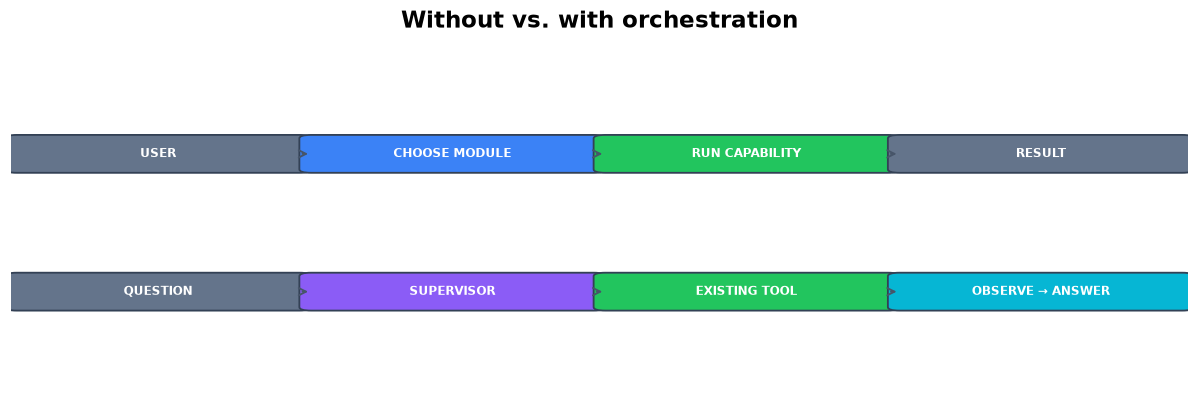

In [ ]:
draw_branch(
    "Without vs. with orchestration",
    boxes=[
        ("USER", .125, .70, "output"), ("CHOOSE MODULE", .375, .70, "system"),
        ("RUN CAPABILITY", .625, .70, "tool"), ("RESULT", .875, .70, "output"),
        ("QUESTION", .125, .30, "output"), ("SUPERVISOR", .375, .30, "supervisor"),
        ("EXISTING TOOL", .625, .30, "tool"), ("OBSERVE → ANSWER", .875, .30, "evidence"),
    ],
    arrows=[
        ((.245,.70),(.255,.70)), ((.495,.70),(.505,.70)), ((.745,.70),(.755,.70)),
        ((.245,.30),(.255,.30)), ((.495,.30),(.505,.30)), ((.745,.30),(.755,.30)),
    ],
    figsize=(11, 4),
)

### What this means

- Direct workspaces still run known capabilities.
- The analyst accepts a business question in natural language.
- The supervisor selects a registered tool and observes its result.
- The same tool services remain in use.

## 3. What is not an agent?

Customer, Analytics, and Knowledge are **capability groupings**, not autonomous specialist agents. There is one supervisor and a registry of existing tools. The tools do domain work; no independent agent teams coordinate with one another.

## 4. Overall architecture

Streamlit sends the request to the FastAPI endpoint. Input checks run before the LangGraph supervisor. The supervisor uses registered tools, observes and validates their results, then continues or finishes. A safe answer and execution evidence return to Streamlit.

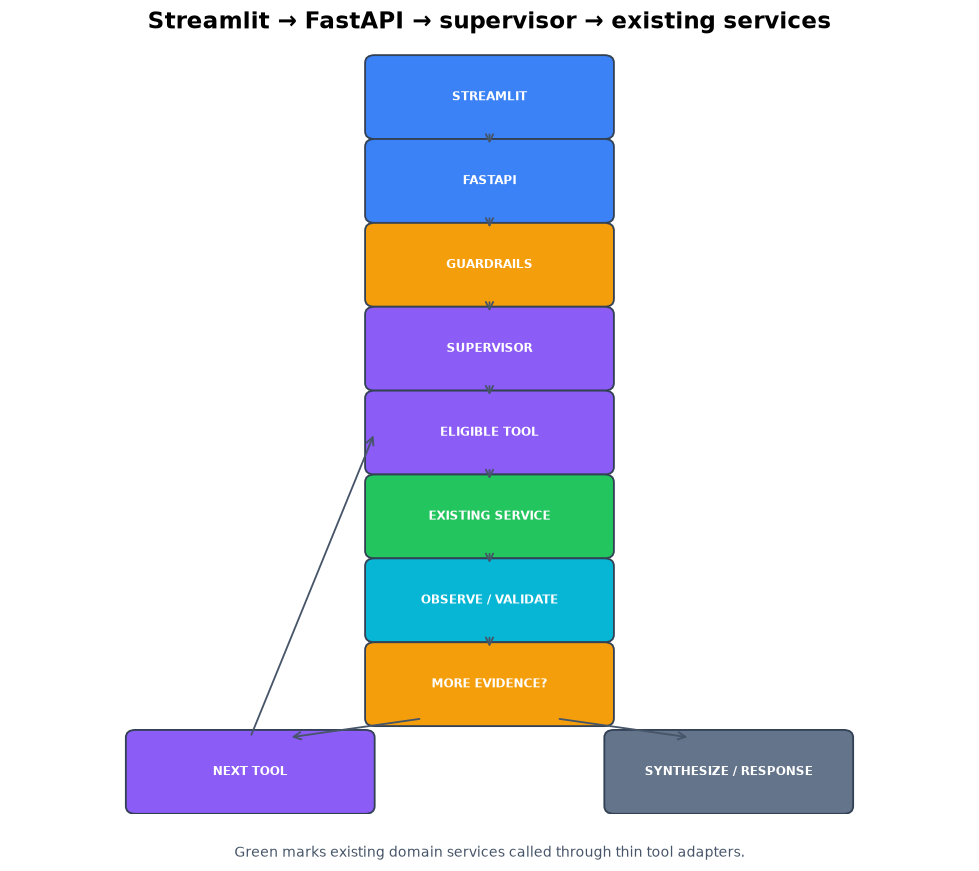

In [ ]:
draw_branch(
    "Streamlit → FastAPI → supervisor → existing services",
    boxes=[
        ("STREAMLIT", .50, .94, "system"), ("FASTAPI", .50, .83, "system"),
        ("GUARDRAILS", .50, .72, "decision"), ("SUPERVISOR", .50, .61, "supervisor"),
        ("ELIGIBLE TOOL", .50, .50, "supervisor"), ("EXISTING SERVICE", .50, .39, "tool"),
        ("OBSERVE / VALIDATE", .50, .28, "evidence"), ("MORE EVIDENCE?", .50, .17, "decision"),
        ("NEXT TOOL", .25, .055, "supervisor"), ("SYNTHESIZE / RESPONSE", .75, .055, "output"),
    ],
    arrows=[
        ((.50,.895),(.50,.875)), ((.50,.785),(.50,.765)), ((.50,.675),(.50,.655)),
        ((.50,.565),(.50,.545)), ((.50,.455),(.50,.435)), ((.50,.345),(.50,.325)),
        ((.50,.235),(.50,.215)), ((.43,.125),(.29,.10)), ((.57,.125),(.71,.10)),
        ((.25,.10),(.38,.50)),
    ],
    note="Green marks existing domain services called through thin tool adapters.",
    figsize=(9, 8),
)

### What this means

- Streamlit collects the question and displays the answer.
- FastAPI provides the request/response boundary.
- Guardrails run before request understanding.
- The supervisor chooses registered tools one action at a time.
- Validated results can cause another tool selection.
- Synthesis returns an answer and concise evidence.

## 5. The Mental Model

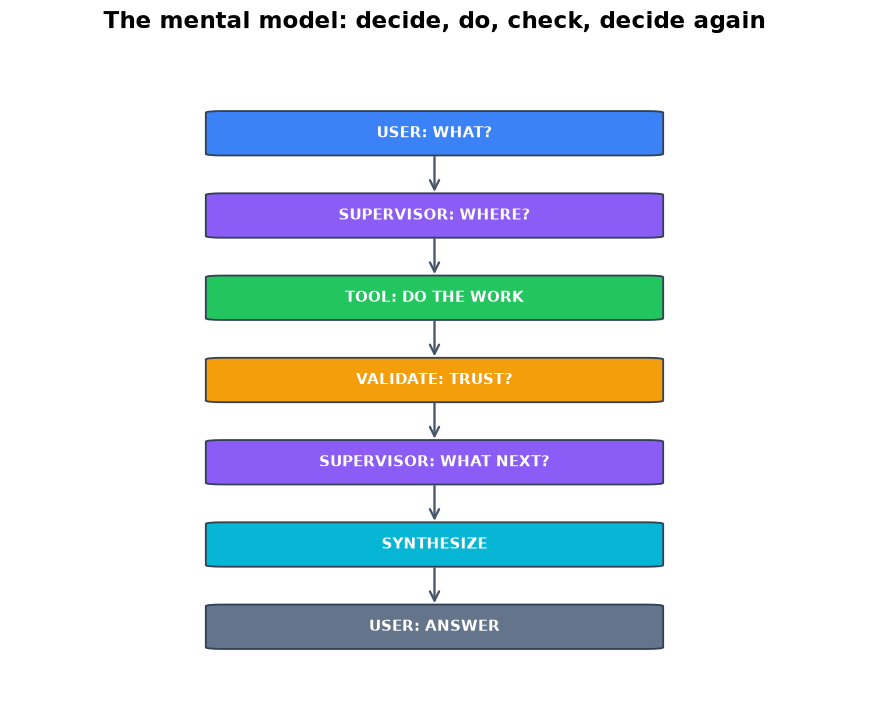

In [ ]:
draw_flow("The mental model: decide, do, check, decide again", [
    ("USER: WHAT?", "system"),
    ("SUPERVISOR: WHERE?", "supervisor"),
    ("TOOL: DO THE WORK", "tool"),
    ("VALIDATE: TRUST?", "decision"),
    ("SUPERVISOR: WHAT NEXT?", "supervisor"),
    ("SYNTHESIZE", "evidence"),
    ("USER: ANSWER", "output"),
], figsize=(8, 7))

### What this means

- The user asks a business question.
- The planner/objective stage interprets the request; the supervisor coordinates selection and execution of eligible tools.
- Existing tools do the ML, analytics, recommendation, forecasting, or RAG work.
- The supervisor observes and validates returned evidence.
- If more evidence is required, it may select another eligible tool.
- Once enough evidence is available, the answer is synthesized and returned.

Only observable actions and decisions are described; hidden chain-of-thought is not exposed.

## 6. Supervisor vs Tool — Who Does What?

| Supervisor | Existing Tool |
|---|---|
| Understands the request | Performs domain work |
| Identifies objectives | Runs analytics, ML, or retrieval logic |
| Selects the next eligible action | Executes the requested operation |
| Maintains request workflow state | Returns structured evidence |
| Observes results | Reports success, failure, or result |
| Decides whether more evidence is needed | Does not orchestrate the global workflow |
| Decides continue or finish | Does not control the whole workflow |
| Synthesizes the final answer | Supplies evidence for synthesis |

**The supervisor decides what should happen next; the tools actually do the business computation.** This is the architecture implemented in this repository.

## 7. Capability map — explanatory grouping, not runtime agent hierarchy

The labels below group registered capabilities to make the system easier to explain. They are **not autonomous agents**, a strict hierarchy, or a required call order. Recommendation is grouped with customer capabilities for this diagram only. The single supervisor selects eligible registered tools using the request, state, and prior results.


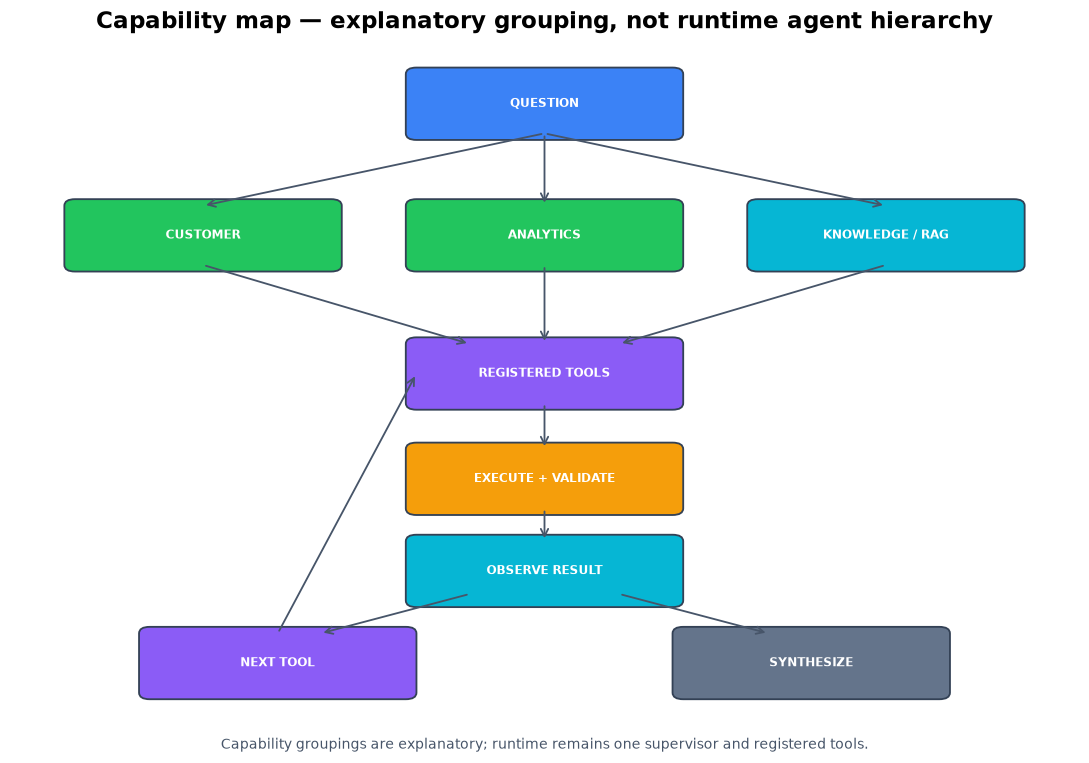

In [ ]:
draw_branch(
    "Capability map — explanatory grouping, not runtime agent hierarchy",
    boxes=[
        ("QUESTION", .50, .92, "system"),
        ("CUSTOMER", .18, .72, "tool"),
        ("ANALYTICS", .50, .72, "tool"),
        ("KNOWLEDGE / RAG", .82, .72, "evidence"),
        ("REGISTERED TOOLS", .50, .51, "supervisor"),
        ("EXECUTE + VALIDATE", .50, .35, "decision"),
        ("OBSERVE RESULT", .50, .21, "evidence"),
        ("NEXT TOOL", .25, .07, "supervisor"),
        ("SYNTHESIZE", .75, .07, "output"),
    ],
    arrows=[
        ((.50,.875),(.18,.765)), ((.50,.875),(.50,.765)), ((.50,.875),(.82,.765)),
        ((.18,.675),(.43,.555)), ((.50,.675),(.50,.555)), ((.82,.675),(.57,.555)),
        ((.50,.465),(.50,.395)), ((.50,.305),(.50,.255)),
        ((.43,.175),(.29,.115)), ((.57,.175),(.71,.115)),
        ((.25,.115),(.38,.51)),
    ],
    note="Capability groupings are explanatory; runtime remains one supervisor and registered tools.",
    figsize=(10, 7),
)

### What this means

- Customer tools cover cohort, RFM, CLV, churn, and recommendation.
- Analytics tools cover KPI and anomaly operations; a forecast tool uses the existing forecast service.
- Knowledge uses the existing RAG retrieval service.
- Registry contracts constrain which operations can execute.
- A result can send the graph to another eligible tool or synthesis.

### A simple map of planner, router, selector, and supervisor

This diagram is a **mental model of responsibilities**. The planner/objective stage interprets the request; the router and selector help identify an eligible next action; the supervisor coordinates graph state, execution, and the continue/finish decision.


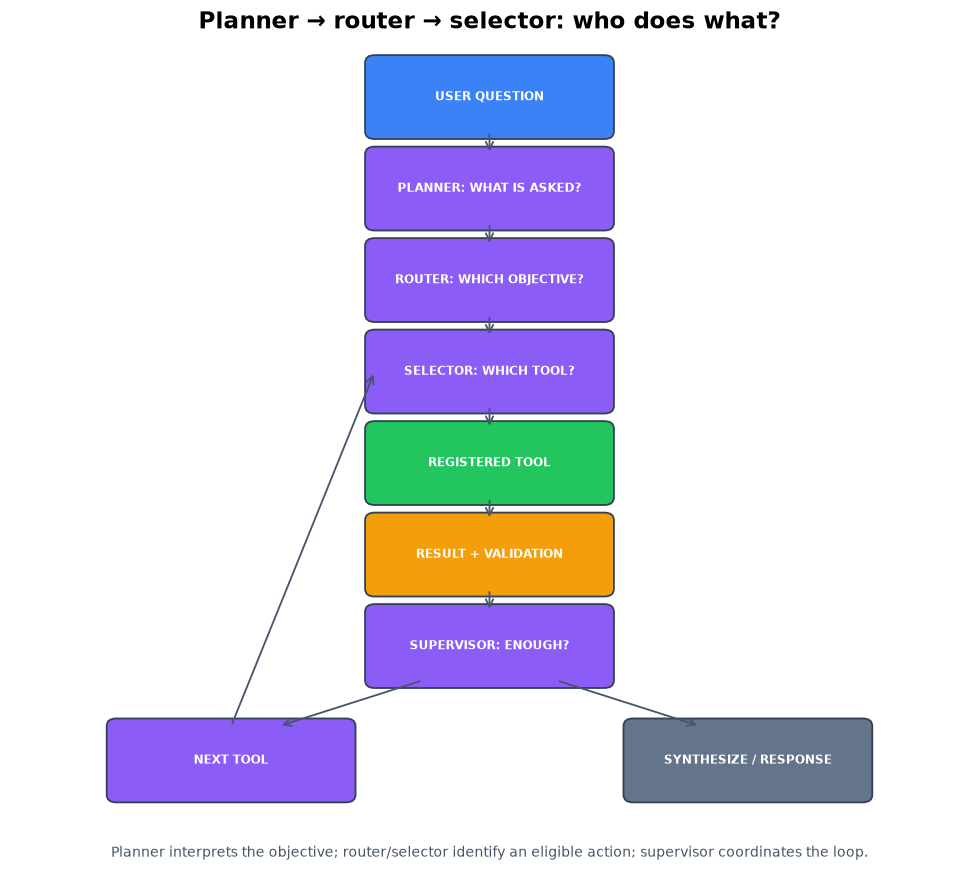

In [ ]:
draw_branch(
    "Planner → router → selector: who does what?",
    boxes=[
        ("USER QUESTION", .50, .94, "system"),
        ("PLANNER: WHAT IS ASKED?", .50, .82, "supervisor"),
        ("ROUTER: WHICH OBJECTIVE?", .50, .70, "supervisor"),
        ("SELECTOR: WHICH TOOL?", .50, .58, "supervisor"),
        ("REGISTERED TOOL", .50, .46, "tool"),
        ("RESULT + VALIDATION", .50, .34, "decision"),
        ("SUPERVISOR: ENOUGH?", .50, .22, "supervisor"),
        ("NEXT TOOL", .23, .07, "supervisor"),
        ("SYNTHESIZE / RESPONSE", .77, .07, "output"),
    ],
    arrows=[
        ((.50,.895),(.50,.865)), ((.50,.775),(.50,.745)), ((.50,.655),(.50,.625)),
        ((.50,.535),(.50,.505)), ((.50,.415),(.50,.385)), ((.50,.295),(.50,.265)),
        ((.43,.175),(.28,.115)), ((.57,.175),(.72,.115)), ((.23,.115),(.38,.58)),
    ],
    note="Planner interprets the objective; router/selector identify an eligible action; supervisor coordinates the loop.",
    figsize=(9, 8),
)

### What this means

- **Planner:** understands the objective; it does not prescribe a static tool queue.
- **Router:** determines an eligible routing path and provides deterministic next-action logic.
- **Selector:** chooses among eligible next actions using the current request and observations.
- **Supervisor:** coordinates graph state, execution, and the conditional continue-or-finish loop.

In the deterministic path, the router can supply the candidate that the selector then constrains/chooses. These are cooperating responsibilities in one orchestration flow, not four autonomous agents. See `backend/app/agents/planner.py`, `router.py`, `selector.py`, and `supervisor.py`.


## 8. Intent, objectives, and tool selection

The request-understanding step may use the configured local Ollama model to return an intent and allowlisted objectives. The response is schema-checked and recognized rule objectives are retained; deterministic rules are the fallback. It does **not** return a fixed tool queue.

The selector starts with host-generated eligible actions. If the optional LLM selector is enabled, it chooses only among those candidates; invalid/unavailable choices fall back to the deterministic selector. The rule path in router.py uses the current objective and validated results to select one next action.

| Responsibility | Actual file |
|---|---|
| Intent/objective understanding | backend/app/agents/planner.py |
| Deterministic objective and next-action fallback | backend/app/agents/router.py |
| Eligible next-action selection | backend/app/agents/selector.py |
| Graph state and conditional flow | backend/app/agents/state.py and supervisor.py |

### Supported route examples from the router (with test coverage where noted)

| Question | Deterministic route | Boundary |
|---|---|---|
| Which customers may churn? | At-risk cohort → RFM → churn | RFM proxy only after registered fallback runs |
| Highest customer lifetime value? | High-value cohort → CLV | Historical value fallback is not predicted CLV |
| Show RFM segments | Cohort → RFM | Descriptive features |
| Which products should we recommend? | Cohort if needed → recommendation | Uses selected platform customer IDs |
| Forecast demand next week | 7-day demand forecast | Existing forecast service/data |
| What are our primary KPIs? | Business analytics | Current selection is one metric at a time |
| Festival revenue planning | Cohort → recommendation → analytics → forecast | No causal campaign-uplift model |
| Ideal customer / buying habits | Cohort → RFM → analytics | Does not calculate a statistical persona |
| Competitor comparison | Default RAG route | No structured competitor dataset |

These describe the deterministic fallback route. Optional LLM choices remain limited to eligible actions.

## 9. State, tool registry, and contracts

The typed AgentState in backend/app/agents/state.py carries the request, objectives, current action, tool calls/results, observations, decision, retries/fallbacks, sources, anomalies, and final response. Memory context is request-only.

backend/app/tools/registry.py is the allowlist and execution boundary. ToolSpec describes each tool, its input schema, output contract, retry limit, and (where configured) fallback. Input and result contracts are checked before validated results become observations.

### Registered tool families

| Capability | Registered tools |
|---|---|
| Customer | customer_cohort_tool, customer_rfm_tool, churn_prediction_tool, clv_prediction_tool |
| Explicit fallback tools | rfm_risk_tool, historical_value_tool |
| Recommendation | recommendation_tool |
| Analytics | business_analytics_tool, anomaly_detection_tool |
| Forecast / review | demand_forecast_tool, sentiment_tool |
| Knowledge | rag_search |

Examples of contracts: churn requires a customer identifier and probability between 0 and 1; CLV values must be finite; forecast values must be numeric and non-negative; RAG needs non-empty retrieved context and source labels. Recommendation results require customer IDs and product-ID lists.

### Actual code map

| Responsibility | Repository file | Role |
|---|---|---|
| Streamlit analyst page | streamlit/pages/13_Agentic_Analyst.py | Ask-a-business-question interface |
| Streamlit request and result display | streamlit/utils/agent_entry.py | POST request and safe evidence summary |
| FastAPI endpoint | backend/app/api/agent.py | POST /agent/ask |
| API prefix | backend/app/main.py | Registers route under configured API prefix |
| Guardrails | backend/app/agents/supervisor.py; backend/app/guardrails/injection.py; pii.py | Lightweight input/output checks |
| Supervisor and state | backend/app/agents/supervisor.py; state.py | LangGraph state and conditional control flow |
| Planner / router / selector | backend/app/agents/planner.py; router.py; selector.py | Objectives, deterministic fallback, eligible actions |
| Tool contracts | backend/app/tools/registry.py | Allowlist and input/output validation |
| Cohort / RFM | backend/app/tools/cohort_tool.py; rfm_tool.py; src/features/customer.py | Existing customer feature construction |
| Churn / CLV | backend/app/tools/churn_tool.py; clv_tool.py | Adapters for saved model services |
| Recommendation / analytics | backend/app/tools/recommendation_tool.py; analytics_tool.py; anomaly_tool.py | Existing commerce capabilities |
| Forecast / sentiment | backend/app/tools/forecast_tool.py; sentiment_tool.py | Existing service adapters |
| RAG | backend/app/tools/rag_tool.py; backend/app/services/rag_service.py | Existing retrieval |
| Synthesis / presentation | backend/app/agents/response.py; presentation.py | Evidence-derived answer and safe API evidence |
| Runtime tests | backend/tests/test_agent_runtime.py | Execution and contract tests |

## 10. Result-aware routing

The supervisor does not simply execute a fixed list of tools. It uses the current objective, state, and validated previous results to determine whether another eligible tool is required.

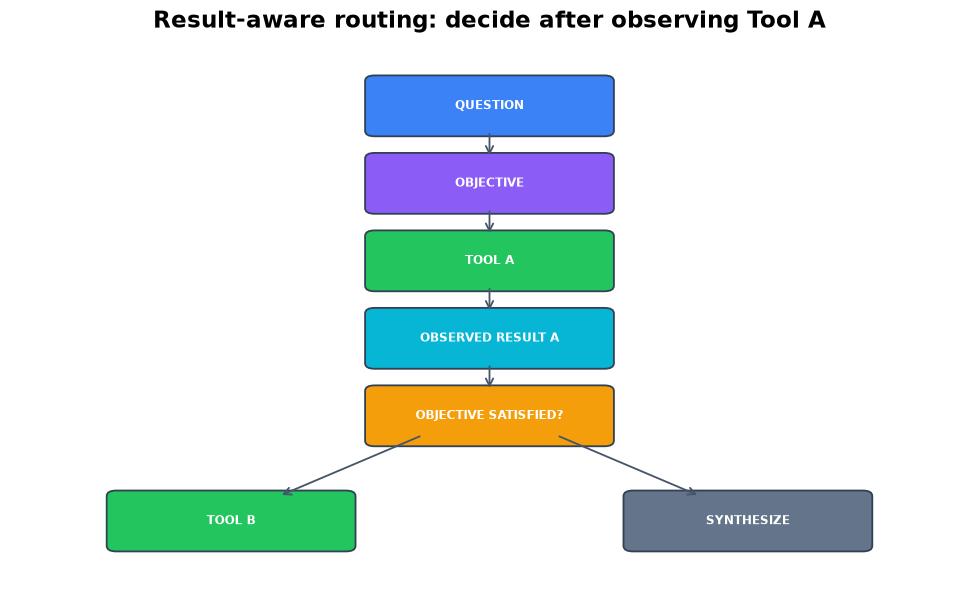

In [ ]:
draw_branch(
    "Result-aware routing: decide after observing Tool A",
    boxes=[
        ("QUESTION", .50, .90, "system"),
        ("OBJECTIVE", .50, .76, "supervisor"),
        ("TOOL A", .50, .62, "tool"),
        ("OBSERVED RESULT A", .50, .48, "evidence"),
        ("OBJECTIVE SATISFIED?", .50, .34, "decision"),
        ("TOOL B", .23, .15, "tool"),
        ("SYNTHESIZE", .77, .15, "output"),
    ],
    arrows=[
        ((.50,.855),(.50,.805)), ((.50,.715),(.50,.665)),
        ((.50,.575),(.50,.525)), ((.50,.435),(.50,.385)),
        ((.43,.305),(.28,.195)), ((.57,.305),(.72,.195)),
    ],
    figsize=(9, 6),
)

### What this means

- Tool A's validated result is part of current state.
- The selector may finish if objectives are resolved.
- If evidence is insufficient, it selects another eligible tool.
- Tool B receives only host-validated inputs, not invented identifiers/features.

The execution test test_tool_result_drives_next_tool_and_inputs checks that a real CLV result is passed into the later churn action.

## 11. Observe → Decide → Act loop

The graph runs one tool action at a time: select → execute → validate → observe → select again or synthesize. A decision summary, tool name, result summary, status, latency, retry/fallback, and sources are observable. Raw hidden reasoning is not part of the response.

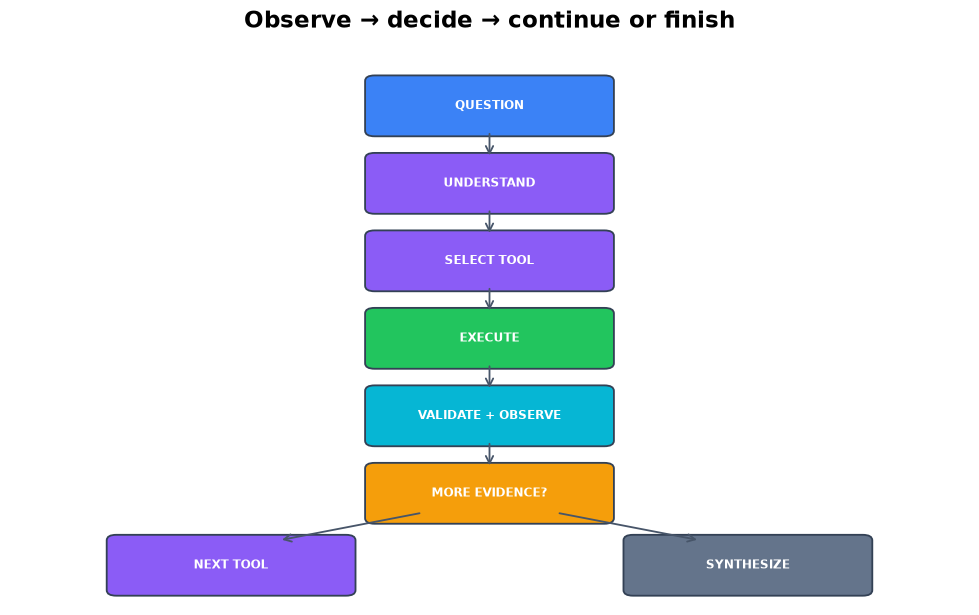

In [ ]:
draw_branch(
    "Observe → decide → continue or finish",
    boxes=[
        ("QUESTION", .50, .90, "system"),
        ("UNDERSTAND", .50, .76, "supervisor"),
        ("SELECT TOOL", .50, .62, "supervisor"),
        ("EXECUTE", .50, .48, "tool"),
        ("VALIDATE + OBSERVE", .50, .34, "evidence"),
        ("MORE EVIDENCE?", .50, .20, "decision"),
        ("NEXT TOOL", .23, .07, "supervisor"),
        ("SYNTHESIZE", .77, .07, "output"),
    ],
    arrows=[
        ((.50,.855),(.50,.805)), ((.50,.715),(.50,.665)),
        ((.50,.575),(.50,.525)), ((.50,.435),(.50,.385)),
        ((.50,.295),(.50,.245)), ((.43,.165),(.28,.115)),
        ((.57,.165),(.72,.115)),
    ],
    figsize=(9, 6),
)

### What this means

- Execute performs one registered operation.
- Validation decides whether its output contract passed.
- Observation stores a compact summary for the next selection.
- The graph can continue, retry, use a registered fallback, or finish.
- Synthesis uses accepted results and labels partial/proxy outcomes.

## 12. Structured data, RAG, or missing evidence?

Choose evidence based on the request. Structured commerce metrics go to existing commerce tools; document questions use indexed retrieval; mixed questions can use both. Validate evidence before synthesis.

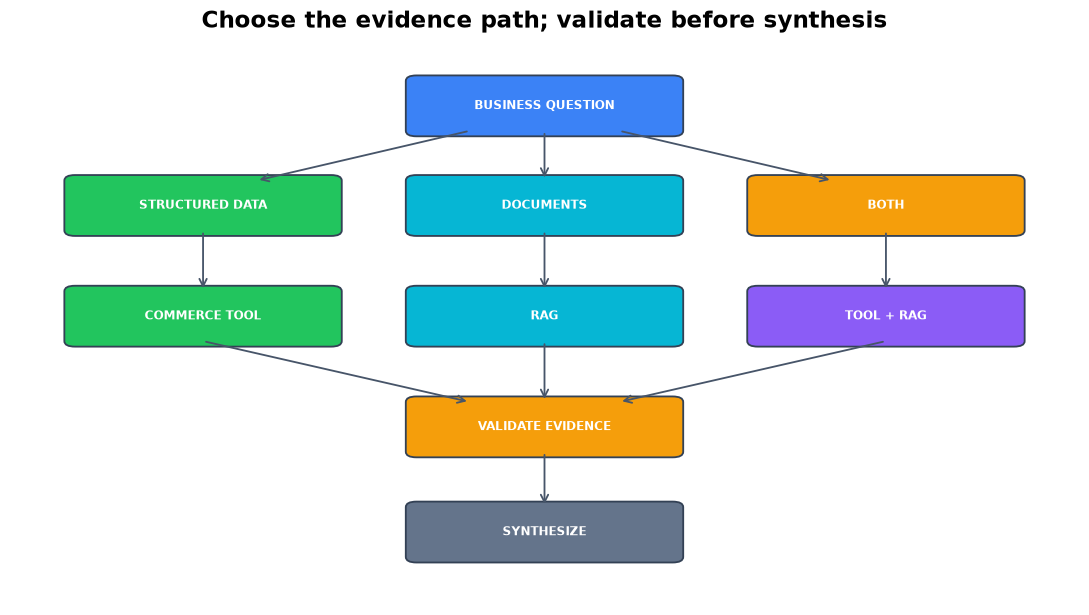

In [ ]:
draw_branch(
    "Choose the evidence path; validate before synthesis",
    boxes=[
        ("BUSINESS QUESTION", .50, .90, "system"),
        ("STRUCTURED DATA", .18, .72, "tool"),
        ("DOCUMENTS", .50, .72, "evidence"),
        ("BOTH", .82, .72, "decision"),
        ("COMMERCE TOOL", .18, .52, "tool"),
        ("RAG", .50, .52, "evidence"),
        ("TOOL + RAG", .82, .52, "supervisor"),
        ("VALIDATE EVIDENCE", .50, .32, "decision"),
        ("SYNTHESIZE", .50, .13, "output"),
    ],
    arrows=[
        ((.43,.855),(.23,.765)), ((.50,.855),(.50,.765)), ((.57,.855),(.77,.765)),
        ((.18,.675),(.18,.565)), ((.50,.675),(.50,.565)), ((.82,.675),(.82,.565)),
        ((.18,.475),(.43,.365)), ((.50,.475),(.50,.365)), ((.82,.475),(.57,.365)),
        ((.50,.275),(.50,.175)),
    ],
    figsize=(10, 6),
)

### What this means

- Project-data answers come from structured commerce tools.
- Document answers use indexed retrieval and returned source labels.
- RAG cannot provide facts absent from its indexed documents.
- Out of dataset does not mean the LLM should guess.

**RAG path:** question → rag_search → retrieved context + source labels → source validation → synthesis. Empty context or missing/invalid source labels is rejected as grounded evidence.

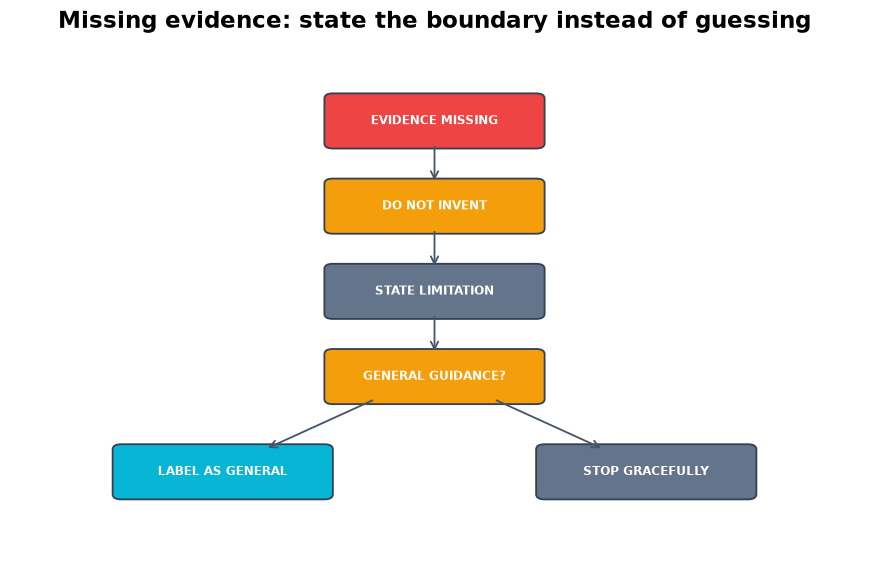

In [ ]:
draw_branch(
    "Missing evidence: state the boundary instead of guessing",
    boxes=[
        ("EVIDENCE MISSING", .50, .86, "failure"),
        ("DO NOT INVENT", .50, .69, "decision"),
        ("STATE LIMITATION", .50, .52, "output"),
        ("GENERAL GUIDANCE?", .50, .35, "decision"),
        ("LABEL AS GENERAL", .25, .16, "evidence"),
        ("STOP GRACEFULLY", .75, .16, "output"),
    ],
    arrows=[
        ((.50,.815),(.50,.735)), ((.50,.645),(.50,.565)),
        ((.50,.475),(.50,.395)), ((.43,.305),(.30,.205)),
        ((.57,.305),(.70,.205)),
    ],
    figsize=(8, 5.5),
)

### Missing-evidence boundary

Do not report competitor metrics, SEO traffic, paid-ad traffic, social traffic, email traffic, customer-support channel distribution, or localization/currency behavior as project facts without data or indexed documents supporting them.

The current response layer returns explicit limitations for known missing-data questions. It does not automatically generate separate general e-commerce advice. If general guidance is added in another flow, label it as **not derived from project data**.

## 13. Retry and actual fallback

For registered churn/CLV tools, retryable failures are retried up to the configured per-tool/global limit (two retries, so up to three primary attempts). After retry exhaustion, the registry's fallback executes if its required inputs validate.

A fallback is another computation/evidence path, not just “service unavailable.” For churn, rfm_risk_tool applies recency_days > 180 and labels its result as a proxy, not a trained model prediction. The execution test test_churn_retry_then_executes_real_rfm_fallback verifies primary calls, both retries, and actual fallback execution.

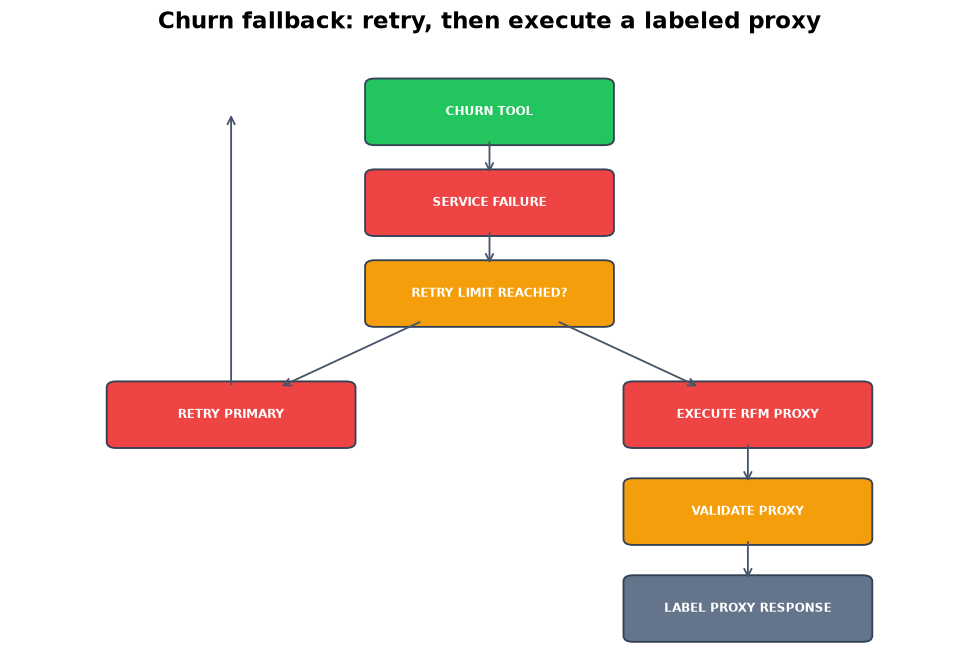

In [ ]:
draw_branch(
    "Churn fallback: retry, then execute a labeled proxy",
    boxes=[
        ("CHURN TOOL", .50, .90, "tool"),
        ("SERVICE FAILURE", .50, .75, "failure"),
        ("RETRY LIMIT REACHED?", .50, .60, "decision"),
        ("RETRY PRIMARY", .23, .40, "failure"),
        ("EXECUTE RFM PROXY", .77, .40, "failure"),
        ("VALIDATE PROXY", .77, .24, "decision"),
        ("LABEL PROXY RESPONSE", .77, .08, "output"),
    ],
    arrows=[
        ((.50,.855),(.50,.795)), ((.50,.705),(.50,.645)),
        ((.43,.555),(.28,.445)), ((.57,.555),(.72,.445)),
        ((.23,.445),(.23,.90)), ((.77,.355),(.77,.285)),
        ((.77,.195),(.77,.125)),
    ],
    figsize=(9, 6.5),
)

### What this means

- The primary model/tool is attempted first.
- Retryable failure gets bounded retries; invalid argument/schema errors do not retry.
- A registered alternative must have valid inputs before it executes.
- The answer calls the result an RFM proxy, never a churn-model prediction.
- If no valid evidence path remains, the graph returns a limitation or partial answer.

### Example: a simple, single-tool question

**Question:** “What is our total revenue?”

**Route illustration:** This is a code-supported single-metric route to `business_analytics_tool` with the revenue metric, followed by validation and synthesis. This is **not a separately captured live execution trace**; no new revenue value is fabricated here. The observed revenue evidence retained from a prior run appears in the Festival example below and is specific to that dataset/runtime.


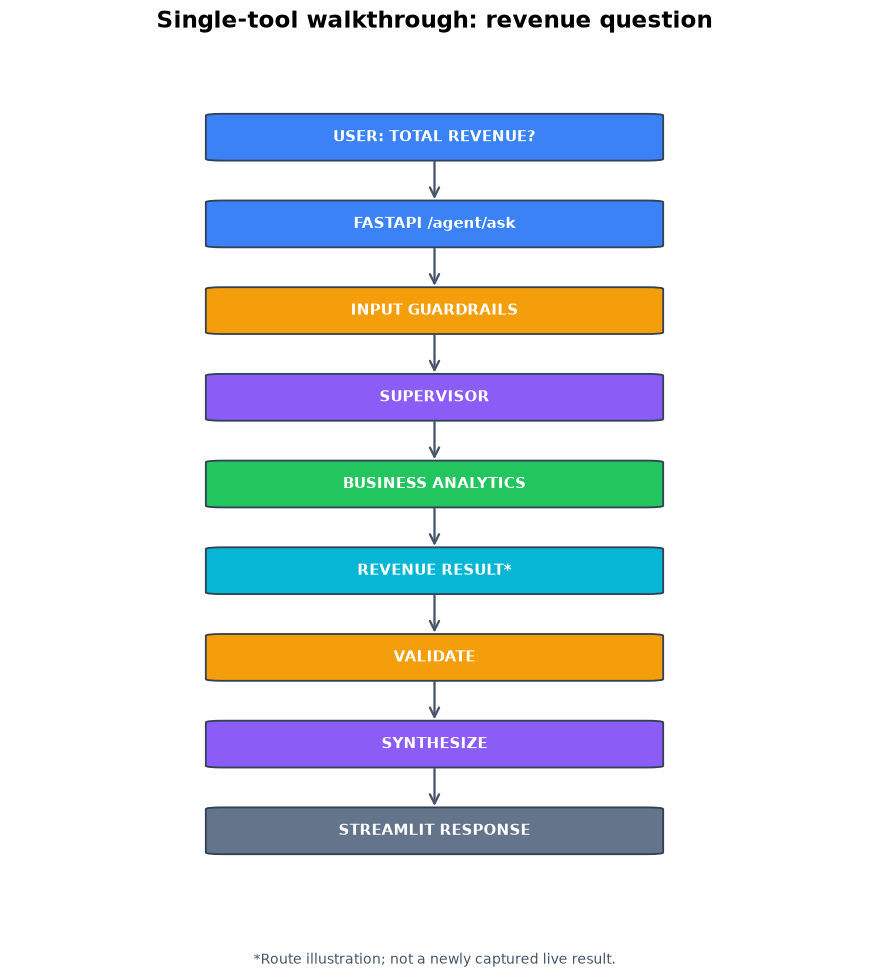

In [ ]:
draw_flow("Single-tool walkthrough: revenue question", [
    ("USER: TOTAL REVENUE?", "system"),
    ("FASTAPI /agent/ask", "system"),
    ("INPUT GUARDRAILS", "decision"),
    ("SUPERVISOR", "supervisor"),
    ("BUSINESS ANALYTICS", "tool"),
    ("REVENUE RESULT*", "evidence"),
    ("VALIDATE", "decision"),
    ("SYNTHESIZE", "supervisor"),
    ("STREAMLIT RESPONSE", "output"),
], note="*Route illustration; not a newly captured live result.", figsize=(8, 9))

### What this means

- The question asks for one structured commerce metric.
- The supervisor routes to the existing business analytics tool.
- The result is validated, then summarized for Streamlit.
- This route is a teaching illustration; the notebook does not claim a new live run for this exact question.

The next example is more complex: the saved execution trace shows multiple customer tools, observed failures, and registered proxy fallbacks.


## 14. End-to-end verified execution trace

**Previously verified execution trace — dataset/runtime dependent**

Question: “Which high-value customers are likely to churn and what products should we recommend?”

This trace includes the actual primary failures and executed registered fallbacks. Counts below are observed values from that run, not architectural constants.

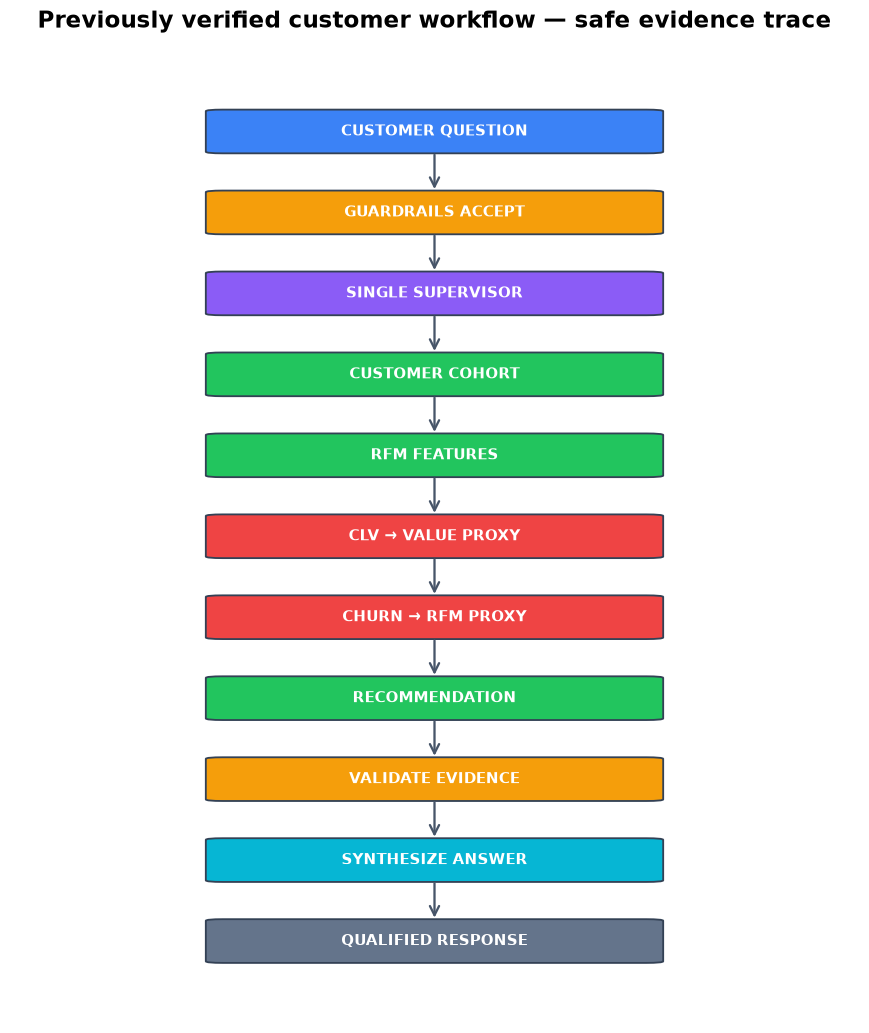

In [ ]:
draw_flow("Previously verified customer workflow — safe evidence trace", [
    ("CUSTOMER QUESTION", "system"),
    ("GUARDRAILS ACCEPT", "decision"),
    ("SINGLE SUPERVISOR", "supervisor"),
    ("CUSTOMER COHORT", "tool"),
    ("RFM FEATURES", "tool"),
    ("CLV → VALUE PROXY", "failure"),
    ("CHURN → RFM PROXY", "failure"),
    ("RECOMMENDATION", "tool"),
    ("VALIDATE EVIDENCE", "decision"),
    ("SYNTHESIZE ANSWER", "evidence"),
    ("QUALIFIED RESPONSE", "output"),
], figsize=(8, 10))

### Tool execution evidence (safe summary)

| Tool | Status | Per-tool latency | Fallback | Evidence/source |
|---|---|---|---|---|
| customer_cohort_tool | Success | Not preserved in saved trace | No | 100 high-value cohort rows; commerce customer data |
| customer_rfm_tool | Success | Not preserved in saved trace | No | RFM features for 100 selected customers |
| clv_prediction_tool | Failed: feature contract | Not preserved | No | Saved CLV artifact could not accept available fields |
| historical_value_tool | Success (proxy) | Not preserved | Yes, for CLV | 50 ranked by observed historical monetary value |
| churn_prediction_tool | Failed: feature contract | Not preserved | No | Saved churn artifact could not accept available fields |
| rfm_risk_tool | Success (proxy) | Not preserved | Yes, for churn | 20 scored by recency heuristic; not model probabilities |
| recommendation_tool | Success | Not preserved | No | 5 recommendation groups from existing recommendation service |

The prior trace summary did not retain per-tool latency or document-source citations; none are invented here. This structured commerce workflow did not use RAG.

### Final answer vs execution evidence

**Evidence:** cohort and RFM ran; saved CLV/churn contracts failed; historical-value and RFM-risk fallbacks ran; recommendation returned groups.

**Faithful conclusion:** recommendations were generated for selected customers, while CLV/churn conclusions are proxy-based because the saved model inputs did not match. This trace does not support a definitive customer persona or trained churn probabilities.

## 15. Festival/revenue planning example

**Previously verified execution trace — dataset/runtime dependent**

Question: “A festival is coming. How can we increase revenue?”

Observed order: cohort (100) → recommendation (5 groups) → business analytics (revenue) → demand forecast (7 points).

Observed execution results: revenue **3,294,778,880** in dataset currency units; first forecast point approximately **1,417.43 per day**. These values describe that dataset/runtime only. They do not demonstrate causal campaign lift. Treat the recommendation as a planning shortlist, not proof of campaign effectiveness.

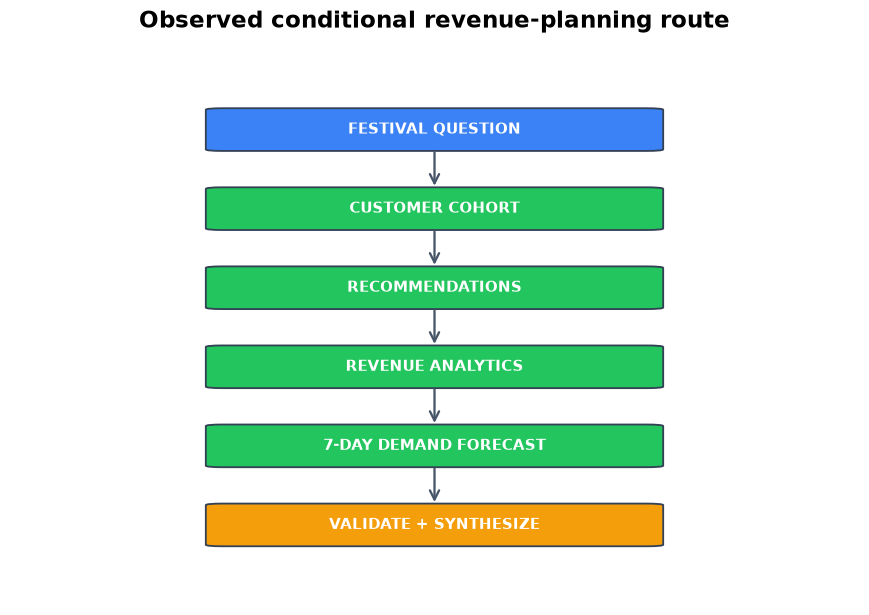

In [ ]:
draw_flow("Observed conditional revenue-planning route", [
    ("FESTIVAL QUESTION", "system"),
    ("CUSTOMER COHORT", "tool"),
    ("RECOMMENDATIONS", "tool"),
    ("REVENUE ANALYTICS", "tool"),
    ("7-DAY DEMAND FORECAST", "tool"),
    ("VALIDATE + SYNTHESIZE", "decision"),
], figsize=(8, 6))

### What this means

- The supervisor selects several capabilities for a broad revenue question.
- The cohort and recommendation results precede the analytics and forecast evidence.
- Revenue and forecast values are specific to that observed dataset/runtime.
- No result proves that a festival campaign will cause incremental revenue.

## 16. KPI question — current capability

**Question:** “What are our primary KPIs?”

The request routes to business analytics. The current deterministic selector returns one metric: explicit order, customer, or AOV wording can change the selection; otherwise it defaults to revenue. The analytics tool has a bounded metric/group-by allowlist, but the runtime does not automatically construct a complete KPI bundle.

### Possible analytical extension — not current runtime behavior

- Revenue / GMV
- Orders
- Customers
- Average Order Value
- Repeat Customer Rate
- Delivery Success Rate
- Review metrics

These measures should not be claimed as one current answer unless a registered operation actually computes and returns that bundle.

## 17. Ideal-customer question — current behavior and boundary

**Question:** “Who is our ideal customer, and what are their buying habits?”

Current deterministic route: customer cohort → RFM features → business analytics. Cohort rows use the existing feature builder and may include real customer identifiers internally; public evidence hides row-level customer records.

The current implementation retrieves cohort/RFM evidence and its synthesizer reports retrieval/counts. It does not automatically perform a complete statistical persona-generation analysis. Do not claim a definitive ideal-customer persona from a sample and feature rows alone.

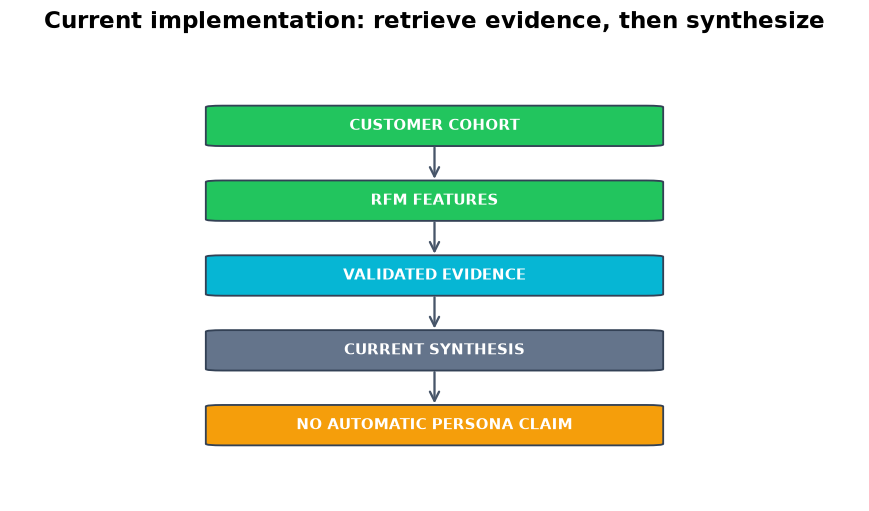

In [ ]:
draw_flow("Current implementation: retrieve evidence, then synthesize", [
    ("CUSTOMER COHORT", "tool"),
    ("RFM FEATURES", "tool"),
    ("VALIDATED EVIDENCE", "evidence"),
    ("CURRENT SYNTHESIS", "output"),
    ("NO AUTOMATIC PERSONA CLAIM", "decision"),
], figsize=(8, 5))

### Analytical extension — NOT currently implemented

For a defensible profile, additional analysis would need to summarize the population, segment customers, identify a high-value/high-frequency/recent segment, and produce a behavior summary. The second diagram is a conceptual extension, not a current runtime route.

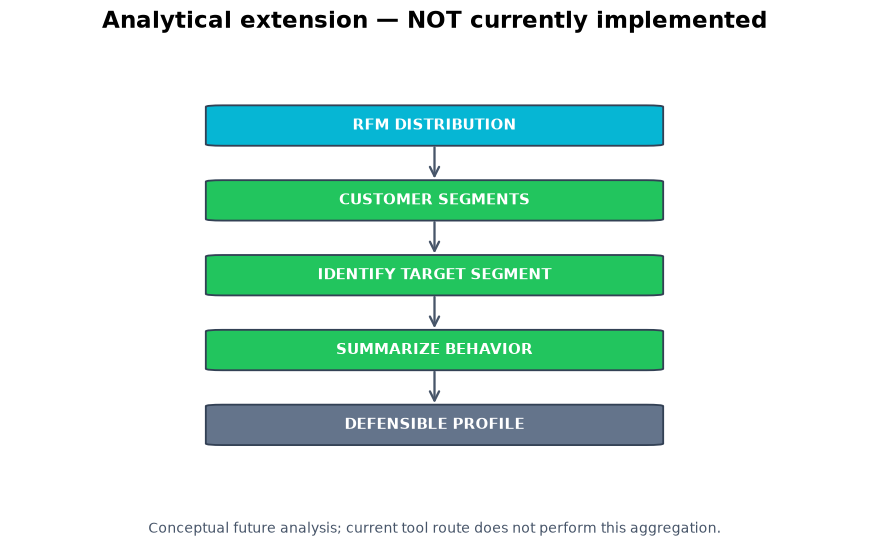

In [ ]:
draw_flow(
    "Analytical extension — NOT currently implemented",
    [
        ("RFM DISTRIBUTION", "evidence"),
        ("CUSTOMER SEGMENTS", "tool"),
        ("IDENTIFY TARGET SEGMENT", "tool"),
        ("SUMMARIZE BEHAVIOR", "tool"),
        ("DEFENSIBLE PROFILE", "output"),
    ],
    note="Conceptual future analysis; current tool route does not perform this aggregation.",
    figsize=(8, 5),
)

### What this means

- Current implementation retrieves a bounded cohort and descriptive RFM features.
- RFM evidence is not automatically a statistically validated persona.
- A stronger profile needs distributions, segmentation, and summarized behavior.
- Until that analytical layer exists, state the evidence limit instead of inventing traits.

## 18. Unsupported competitor question

**Question:** “How do we compare with competitors?”

The default route is RAG. A previously verified run retrieved seller/delivery guidance with the source label policies_faq; synthesis still stated that structured competitor/market-share data are absent and the retrieved guidance does not establish a factual competitor comparison.

**Evidence category:** retrieved document context, not competitor metrics. The limitation remains explicit.

### Optional: inspect or rerun the local graph

Execution is opt-in. It requires the repository environment, prepared data, model artifacts, and an available retrieval index. The output below contains safe summaries rather than raw customer rows or full retrieved documents.

In [ ]:
from pathlib import Path
import sys

def find_project_root(start=None):
    here=(start or Path.cwd()).resolve()
    for candidate in (here,*here.parents):
        if (candidate/"backend"/"app"/"agents"/"supervisor.py").exists():
            return candidate
    raise FileNotFoundError("Open this notebook from the repository or a child folder.")

PROJECT_ROOT=find_project_root()
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0,str(PROJECT_ROOT))
from backend.app.agents.supervisor import agent_graph, MAX_ITERATIONS, MAX_RETRIES, run_agent
from backend.app.tools.registry import TOOL_REGISTRY
print("Graph nodes:",", ".join(agent_graph.get_graph().nodes))
print("Limits:",{"max_iterations":MAX_ITERATIONS,"max_retries":MAX_RETRIES})
print("Registered tools:",", ".join(TOOL_REGISTRY))

In [ ]:
RUN_LIVE_EXAMPLES=False
QUESTIONS=[
 "Which high-value customers are likely to churn and what products should we recommend?",
 "A festival is coming. How can we increase revenue?",
 "How do we compare with competitors?",
]

if RUN_LIVE_EXAMPLES:
    for question in QUESTIONS:
        result=run_agent(question)
        print({
            "question":question,
            "answer":result.get("answer","")[:700],
            "intent":result.get("intent"),
            "tool_evidence":[(item["tool"],item["status"],item.get("elapsed_ms"),item.get("fallback_used"))
                            for item in result.get("evidence",[])],
            "iterations":result.get("iterations"),
            "latency_ms":result.get("latency_ms"),
            "fallback_used":result.get("fallback_used"),
            "sources":result.get("sources"),
            "task_success":(result.get("evaluation") or {}).get("task_success"),
        })
else:
    print("Live execution is off. Set RUN_LIVE_EXAMPLES=True when the local runtime is ready.")

## 19. Guardrails and safety scope

The supervisor checks non-empty/length-bounded questions, a small set of prompt-injection patterns, email/phone-like PII in selected request fields, and certain vague questions that need clarification. Output presentation removes row-level customer data and full document bodies; the response guard redacts contact details and checks RAG source labels.

These are lightweight demo checks. Production-grade toxicity detection, advanced misuse detection, and comprehensive policy enforcement are not implemented.

## 20. Existing test evidence

The repository test file backend/tests/test_agent_runtime.py includes:

- test_tool_result_drives_next_tool_and_inputs — observed CLV output changes later churn input.
- test_anomaly_result_controls_conditional_rag_tool_call — anomaly evidence controls RAG selection.
- test_churn_retry_then_executes_real_rfm_fallback — two retries and actual proxy execution.
- test_failed_churn_result_prevents_recommendation_without_fallback — downstream recommendation is withheld without valid churn/proxy evidence.
- Contract tests for churn, CLV, forecast, recommendation, analytics, and RAG.
- Competitor limitation, cohort feature-building, and privacy-safe evidence tests.

These are test cases in the repository, not claims that this notebook edit reran the suite.

## 21. Limitations and what is not claimed

- One supervisor, not multiple autonomous agents.
- No long-term persistent memory; state is request-scoped.
- No unrestricted autonomous planning across arbitrary tools.
- No complete statistical ideal-customer persona or automatic KPI dashboard bundle.
- No production-grade toxicity/misuse detection.
- No fabricated external competitor, traffic, support, or currency data.
- General LLM business guidance is not an automatic current response path.
- KV cache is an inference-engine optimization; this application does not manage internal LLM KV state.

**Accurate summary:** one supervisor orchestrates bounded registered services, observes validated results, and returns a safe evidence summary.

## 22. What is actually implemented?

| Capability | Current status |
|---|---|
| Single supervisor | Implemented |
| LangGraph orchestration | Implemented |
| Tool registry and schemas | Implemented |
| Result-aware routing | Implemented |
| Customer cohort / RFM capability | Implemented |
| Churn and CLV model adapters | Implemented; saved model contract may fail for available features |
| Analytics capability | Implemented; selected metric/group-by operations |
| Recommendation capability | Implemented |
| Forecasting capability | Implemented |
| RAG capability | Implemented over indexed documents |
| Guardrails | Implemented / lightweight |
| Bounded retry | Implemented |
| Registered proxy fallbacks | Implemented for churn and CLV |
| Long-term memory | Not implemented / out of scope |
| Autonomous specialist agents | Not implemented |
| Raw hidden chain-of-thought in API/UI | Not exposed |
| Guessing missing project facts | Not allowed |
| Full ideal-customer persona / KPI bundle | Not implemented as an automatic analysis |

## 23. Final architecture

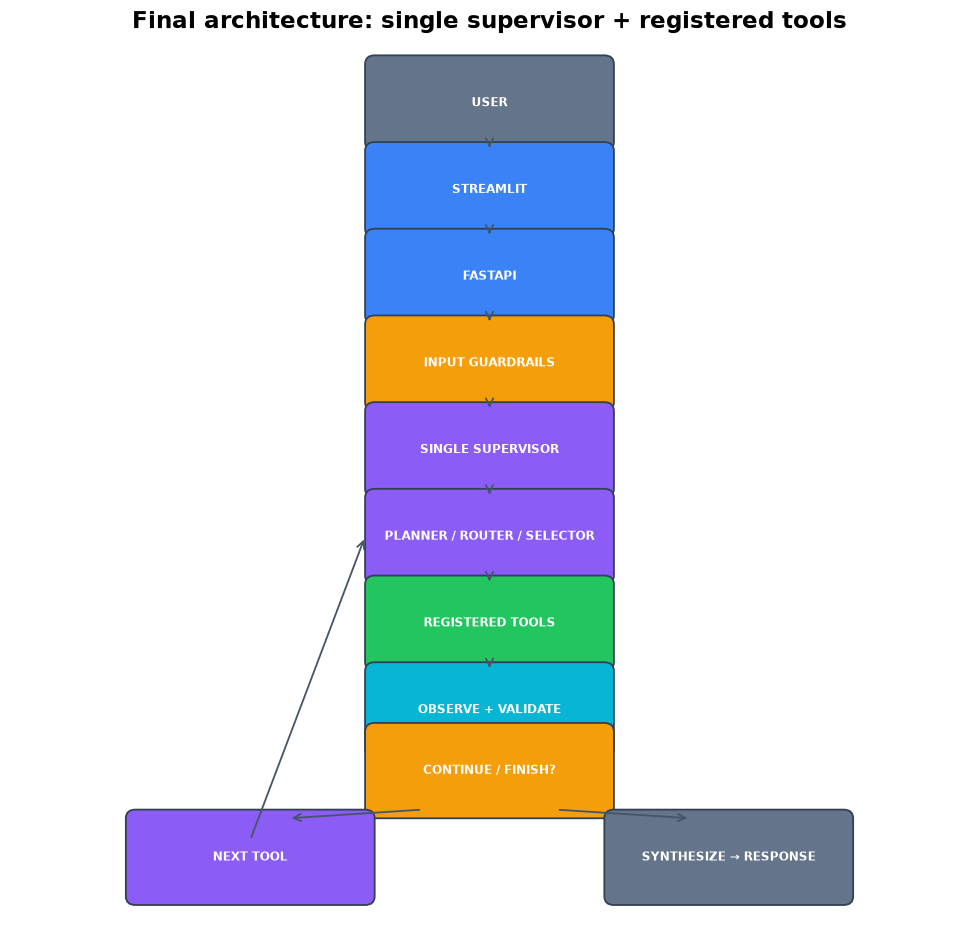

In [ ]:
draw_branch(
    "Final architecture: single supervisor + registered tools",
    boxes=[
        ("USER", .50, .94, "output"), ("STREAMLIT", .50, .84, "system"),
        ("FASTAPI", .50, .74, "system"), ("INPUT GUARDRAILS", .50, .64, "decision"),
        ("SINGLE SUPERVISOR", .50, .54, "supervisor"),
        ("PLANNER / ROUTER / SELECTOR", .50, .44, "supervisor"),
        ("REGISTERED TOOLS", .50, .34, "tool"), ("OBSERVE + VALIDATE", .50, .24, "evidence"),
        ("CONTINUE / FINISH?", .50, .17, "decision"),
        ("NEXT TOOL", .25, .07, "supervisor"), ("SYNTHESIZE → RESPONSE", .75, .07, "output"),
    ],
    arrows=[
        ((.50,.895),(.50,.885)), ((.50,.795),(.50,.785)), ((.50,.695),(.50,.685)),
        ((.50,.595),(.50,.585)), ((.50,.495),(.50,.485)), ((.50,.395),(.50,.385)),
        ((.50,.295),(.50,.285)), ((.43,.125),(.29,.115)), ((.57,.125),(.71,.115)),
        ((.25,.09),(.37,.44)),
    ],
    figsize=(9, 9),
)

### What this means

- Streamlit → FastAPI → input checks → one supervisor.
- Planner/router/selector determine one eligible next action.
- Registered tools call existing business services.
- The graph validates and observes results before continuing or finishing.
- Synthesis returns an evidence-grounded answer and safe execution details.

## 24. Summary

“This project uses a single LangGraph supervisor as the orchestration layer. A business user asks a question through Streamlit, which sends it to FastAPI. Guardrails validate the request before the planner/objective stage interprets it; the supervisor then coordinates execution. The supervisor does not perform the ML or analytics itself. It selects from registered tools that wrap the existing commerce, ML, recommendation, forecasting, and RAG services. After a tool executes, the supervisor observes and validates the result. If the objective is not satisfied, it can select another eligible tool based on the current state and evidence. Once enough evidence is available, the system synthesizes a grounded response and returns it to Streamlit. If required evidence is unavailable, it does not invent an answer; it states the limitation.”

## Notebook validation and scope

Live scenario execution is opt-in because it requires the repository runtime, prepared data, model artifacts, and retrieval index. Examples above are labeled as previously verified execution traces or repository test evidence; conceptual extensions are labeled separately.

The linked implementation paths were checked against this repository. Diagram cells render Matplotlib figures directly; no Mermaid source is presented as a substitute for the diagrams. This notebook-only task does not modify backend behavior, ML models, RAG, tool implementations, FastAPI contracts, Streamlit business logic, Docker configuration, or notebooks 01–10.